## A-1. Linear Regression from Scratch

このNotebookでは、Linear Regression（線形回帰）をPythonとNumPyを使ってゼロから実装する。
scikit-learnなどの機械学習ライブラリは、まずは使用しない。
### What we will learn
- データを生成する
- 線形モデルを定義する
- Loss function（損失関数）を定義する
- Gradient（勾配）を計算する
- Gradient Descent（勾配降下法）でパラメータを更新する
- 学習結果を可視化する

最終的に、
\[
y = ax + b
\]
というモデルのパラメータ \(a, b\) を、データから学習できるようにする。

---
### Machine Learning Flow
このNotebookでは、機械学習の基本的な流れを以下のように捉える。

$$
\text{Model}
\rightarrow
\text{Loss}
\rightarrow
\text{Gradient}
\rightarrow
\text{Parameter Update}
$$

この流れを、できるだけブラックボックスにせず理解する。

### 1. Import Libraries

まず、数値計算とデータの可視化に必要なライブラリをimportする。

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

### 2. Generate Data

今回は、以下の関係を持つ人工データを作る。

$$
y = 2x + 1
$$

つまり、本来のパラメータは

$$
a = 2,\qquad b = 1
$$

である。

この関係にランダムなノイズを加えることで、実際の観測データを模擬する。

最終的には、このデータだけを見て、

$$
y = ax + b
$$

の $a$ と $b$ を学習によって推定する。

In [4]:
#np.random.seed(42)  #seedを指定すると、固定された乱数が生成される。

x = np.linspace(0, 10, 100)
noise = np.random.normal(0, 1, 100)

y = 2 * x + 1 + noise

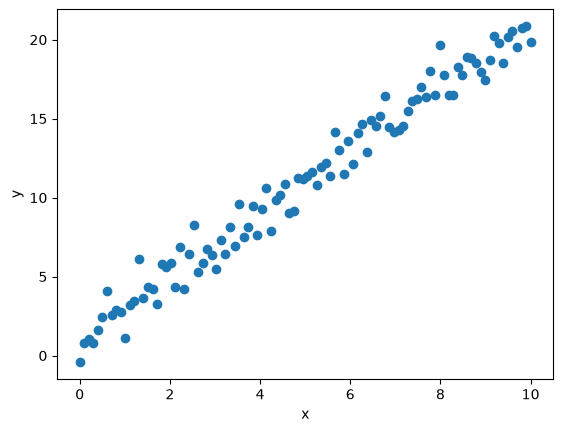

In [5]:
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

#### 3. Inspect the Data

作成した `x` と `y` が、Pythonの中でどのようなオブジェクトとして扱われているのか確認する。

In [ ]:
print(type(x))
print(type(y))
print(x.shape)
print(y.shape)
print(x.dtype)
print(y.dtype)
print(x.nbytes)
print(y.nbytes)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(100,)
(100,)
float64
float64
800
800


### 4. Linear Regression

今回は、モデルとして1次関数

$$
\hat{y}=ax+b
$$

を用いる。

実際の値 $y$ と予測値 $\hat{y}$ の差を評価するため、Lossとして誤差の二乗平均を用いる。

$$
L(a,b)
=
\frac{1}{N}
\sum_{i=1}^{N}
(\hat{y}_i-y_i)^2
$$

In [6]:
a = 0.0
b = 0.0
y_pred = a * x + b

N = len(y)

loss = np.mean((y_pred - y) ** 2)

print(loss)

156.46691465948106


このLossを小さくするために、$a$ と $b$ に関する微分（Gradient）を計算し、パラメータを更新する。

$$
\frac{\partial L}{\partial a},
\qquad
\frac{\partial L}{\partial b}
$$

Gradientの情報を使ってLossが小さくなる方向に $a,b$ を更新すると、最終的にモデルはデータにフィットしていく。

つまり、

$$
\boxed{
\text{Model}
\rightarrow
\text{Loss}
\rightarrow
\text{Gradient}
\rightarrow
\text{Parameter Update}
}
$$

という流れで、データから最適なパラメータを学習できる。

a = 2.002738493168148
b = 1.0074212036363401


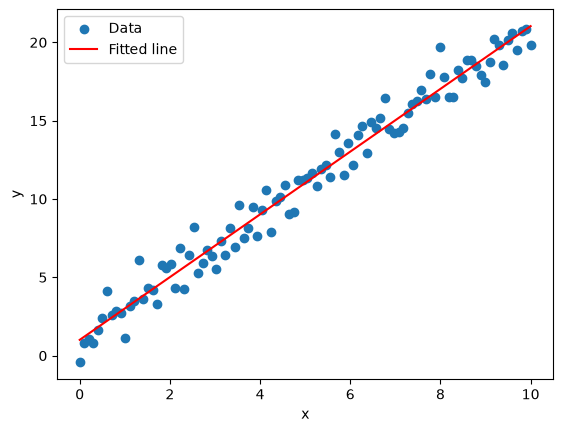

In [7]:
learning_rate = 0.01
epochs = 1000

for _ in range(epochs):

    # Model
    y_pred = a * x + b

    # Loss
    loss = np.mean((y_pred - y) ** 2)

    # Gradient
    grad_a = (2 / N) * np.sum((y_pred - y) * x)
    grad_b = (2 / N) * np.sum(y_pred - y)

    # Parameter update
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b

print("a =", a)
print("b =", b)

# Final prediction
y_pred = a * x + b

# Plot
plt.scatter(x, y, label="Data")
plt.plot(x, y_pred, label="Fitted line", color="red")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()